# EC-Earth Aitken:Accumulation Ratio — Station Clustering

**Scientific question:** Do the EC-Earth stations fall into distinct aerosol regimes based on their **Aitken-to-accumulation number ratio** (N20–100 / N100) at the lowest cloud level? K-means clusters stations by this ratio to group them into regime types (e.g. clean marine vs polluted continental).

The ratio is computed from CCN at 20 nm and 100 nm cutoffs via `ECEarthERF`, using the standardized `ECearthExtract_Dask` loader (IFS regridded onto 34 model levels, CDNC masked at 80% cloud cover).

**Clustering level:** lowest cloud level (`lev=1`, ~987 hPa). The surface (`lev=0`) has no liquid cloud; valid CDNC/CCN concentrates in the lower troposphere.

---
*Sections: 1 Setup · 2 Build Ait:Acc ratio · 3 Choose k (elbow + silhouette) · 4 Cluster · 5 Groups.*

## 1 · Setup and configuration

In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [7]:
EC_PATH = "/share/sabl0586/all_stations_EC-Earth_PRCP2SZDST_ilevall_levs_4Peter.nc"
D_GRID  = xr.DataArray(np.logspace(-0.5, 3, num=200), dims=['D'],
                       coords={'D': np.logspace(-0.5, 3, num=200)})
CLUSTER_LEV = 1          # lowest cloud level (~987 hPa); lev=0 is empty of liquid cloud
N_CLUSTERS  = 3          # chosen from the elbow/silhouette diagnostics in Section 3
RANDOM_STATE = 2

## 2 · Build the Aitken:Accumulation ratio per station

For each station, the standardized loader returns aerosol modes on the 34 levels; `ECEarthERF` integrates CCN at 20 nm and 100 nm. The Aitken number is the 20–100 nm difference, accumulation is N100, and the ratio is Aitken/accumulation.

In [5]:
ds = xr.open_dataset(EC_PATH, chunks={})
stations = ds['station'].values

ratios = []
for station in stations:
    EC_ds = Function.ECearthExtract_Dask(EC_PATH, station, [], [], D_GRID, PNSD=False)
    AitAcc = Function.ECEarthERF(EC_ds, [20, 100])
    N100 = AitAcc.sel(radius=100)
    N20  = AitAcc.sel(radius=20) - AitAcc.sel(radius=100)   # 20-100 nm = Aitken
    ratio = ((N20 - N100) / N100).isel(lev=CLUSTER_LEV)              # lowest cloud level
    ratios.append(ratio.assign_coords(station=station))

AitAccRatio = xr.concat(ratios, dim='station').compute()    # (station, time)
print(AitAccRatio.dims, AitAccRatio.shape)

('station', 'time') (15, 61369)


## 3 · Choose the number of clusters (elbow + silhouette)

Two diagnostics side by side. The **elbow** (inertia vs k) shows diminishing returns; the **silhouette** score (higher = better-separated clusters) gives a less subjective optimum. Where they agree is a defensible k.

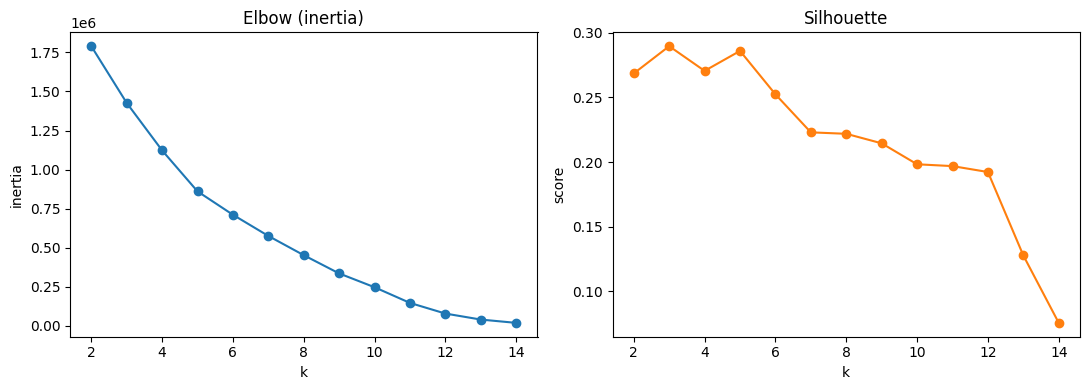

silhouette-optimal k = 3


In [6]:
# Each station is one sample; its feature vector is the time series of the ratio.
X = AitAccRatio.dropna('time', how='all').fillna(0.0).values   # (station, time)

ks = range(2, min(15, len(stations)))
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, init='k-means++', n_init=10).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inertias, 'o-'); ax1.set(title='Elbow (inertia)', xlabel='k', ylabel='inertia')
ax2.plot(list(ks), silhouettes, 'o-', color='C1'); ax2.set(title='Silhouette', xlabel='k', ylabel='score')
plt.tight_layout(); plt.show()

best_k = list(ks)[int(np.argmax(silhouettes))]
print('silhouette-optimal k =', best_k)

## 4 · Cluster the stations

In [8]:
km = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, init='k-means++', n_init=10).fit(X)

clustered = AitAccRatio.dropna('time', how='all').to_dataset(name='AitAccRatio')
clustered['label'] = xr.DataArray(km.labels_, dims=('station',))
clustered = clustered.assign_coords(station=stations[:len(km.labels_)])

## 5 · Cluster membership

In [9]:
# Print which stations fall in each cluster.
for c in range(N_CLUSTERS):
    members = clustered.station.where(clustered.label == c, drop=True).values
    members_str = ', '.join(str(s) for s in members)
    print(f'Cluster {c}: {members_str}')

Cluster 0: SMR-II, MHD, BIR-II, Vavihill, JFJ
Cluster 1: ZEP, ATTO, SGP, CHC, FKL, Villum, Izana, Maldives
Cluster 2: PAL, SMEAR-I


In [10]:
# Mean ratio per cluster (regime strength), for interpretation.
for c in range(N_CLUSTERS):
    mask = clustered.label == c
    mean_ratio = float(clustered.AitAccRatio.where(mask).mean().values)
    print(f'Cluster {c}: mean Aitken:Accumulation = {mean_ratio:.3f}')

Cluster 0: mean Aitken:Accumulation = 3.778
Cluster 1: mean Aitken:Accumulation = 1.926
Cluster 2: mean Aitken:Accumulation = 3.562
